In [20]:
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import os
from IPython.display import display, HTML
import matplotlib.patheffects as PathEffects

# --- CONFIGURATION ---
DB_PATH = "db/results.sqlite" 
sns.set_theme(style="whitegrid", context="paper")

In [21]:
# --- CUSTOM CSS FOR DASHBOARD ---
DASHBOARD_CSS = """
<style>
    :root {
        --bg-color: #ffffff;
        --text-color: #2c3e50;
        --accent: #3498db;
        --border: #e0e0e0;
        --success: #27ae60;
        --warning: #f39c12;
        --danger: #c0392b;
    }
    .db-container { font-family: 'Segoe UI', sans-serif; max-width: 100%; color: var(--text-color); }
    .db-header { background: #f8f9fa; padding: 15px; border-bottom: 2px solid var(--accent); margin-bottom: 20px; }
    .db-stat-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(120px, 1fr)); gap: 10px; margin-bottom: 20px; }
    .db-stat-card { background: #fff; border: 1px solid var(--border); padding: 10px; text-align: center; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05); }
    .db-stat-val { font-size: 1.2em; font-weight: bold; }
    .db-stat-label { font-size: 0.8em; color: #7f8c8d; text-transform: uppercase; }
    .cluster-card { border: 1px solid var(--border); margin-bottom: 25px; border-radius: 6px; overflow: hidden; box-shadow: 0 2px 5px rgba(0,0,0,0.05); }
    .cluster-head { padding: 10px 15px; display: flex; justify-content: space-between; align-items: center; background: #f1f2f6; border-bottom: 1px solid var(--border); }
    .cluster-title { font-weight: bold; font-size: 1.1em; }
    .acc-container { display: flex; align-items: center; gap: 10px; }
    .acc-bar-bg { width: 100px; height: 8px; background: #ddd; border-radius: 4px; overflow: hidden; }
    .acc-bar-fill { height: 100%; transition: width 0.3s; }
    .metric-table { width: 100%; border-collapse: collapse; font-size: 0.9em; margin: 10px 0; }
    .metric-table th { text-align: left; padding: 8px; border-bottom: 1px solid #ddd; color: #7f8c8d; }
    .metric-table td { padding: 8px; border-bottom: 1px solid #eee; }
    .shift-bar-container { width: 100px; height: 6px; background: #eee; position: relative; border-radius: 2px; }
    .shift-bar { height: 100%; position: absolute; top: 0; }
    details { margin: 0; border-top: 1px solid #eee; }
    summary { padding: 10px 15px; cursor: pointer; background: #fff; font-weight: 500; color: var(--accent); user-select: none; }
    summary:hover { background: #f8f9fa; }
    .ex-content { padding: 15px; background: #fafafa; border-top: 1px solid #eee; font-family: monospace; white-space: pre-wrap; font-size: 0.85em; max-height: 400px; overflow-y: auto; }
    .status-badge-pass { background: var(--success); color: white; padding: 2px 6px; border-radius: 4px; font-size: 0.75em; vertical-align: middle; }
    .status-badge-fail { background: var(--danger); color: white; padding: 2px 6px; border-radius: 4px; font-size: 0.75em; vertical-align: middle; }
    .gold-box { border-left: 3px solid var(--success); padding-left: 10px; margin: 5px 0; color: #444; background: rgba(39, 174, 96, 0.05); padding: 5px; }
    .pred-box { border-left: 3px solid var(--accent); padding-left: 10px; margin: 5px 0; color: #444; background: rgba(52, 152, 219, 0.05); padding: 5px; }
</style>
"""

def generate_cluster_html(c_id, count, acc, metrics_html, examples_html):
    if acc >= 80: acc_color = "var(--success)"
    elif acc >= 50: acc_color = "var(--warning)"
    else: acc_color = "var(--danger)"
    
    return f"""
    <div class="cluster-card">
        <div class="cluster-head" style="border-left: 5px solid {acc_color}">
            <div class="cluster-title">CLUSTER {c_id}</div>
            <div class="acc-container">
                <span style="font-size: 0.9em; font-weight: bold;">{acc:.1f}% Acc</span>
                <div class="acc-bar-bg"><div class="acc-bar-fill" style="width: {acc}%; background: {acc_color};"></div></div>
                <span style="font-size: 0.8em; color: #666;">({count} Samples)</span>
            </div>
        </div>
        <div style="padding: 15px;">
            <table class="metric-table">
                <thead><tr><th>Metric</th><th>Shift (SD)</th><th>Mean</th><th>SD</th><th>Vis</th></tr></thead>
                <tbody>{metrics_html}</tbody>
            </table>
        </div>
        <details>
            <summary>View Representative Examples ({count})</summary>
            <div class="ex-content">{examples_html}</div>
        </details>
    </div>
    """

In [22]:
def load_latest_data(db_path):
    if not os.path.exists(db_path):
        print(f"❌ Database not found at {db_path}")
        return None, None

    conn = sqlite3.connect(db_path)
    
    # 1. Get Latest Experiment
    exp_query = "SELECT experiment_id, name FROM Experiments ORDER BY experiment_id DESC LIMIT 1"
    try:
        exp_df = pd.read_sql(exp_query, conn)
        if exp_df.empty: return None, None
        latest_exp = exp_df.iloc[0]
        latest_id, name = latest_exp['experiment_id'], latest_exp['name']
    except Exception as e:
        print(f"Error finding experiment: {e}")
        return None, None

    print(latest_id)
    # 2. Get Results
    res_query = f"""
    SELECT r.result_id, r.question_id_external, r.question_text, r.gold_answer, 
           r.predicted_answer, r.full_trace_text, r.is_correct,
           r.uq_avg_entropy as 'Entropy', r.uq_min_logit_gap as 'LogitGap',
           r.uq_heuristic_score as 'Heuristic', r.uq_mech_score as 'Mechanistic'
    FROM Results r WHERE r.experiment_id = {latest_id}
    """
    
    try:
        df = pd.read_sql(res_query, conn)
        conn.close()
        
        if df.empty: return None, latest_id
        df['Correct'] = df['is_correct'].astype(int)
        
        # 3. Calculate Semantic Entropy (On-the-fly)
        def calc_semantic_entropy(sub):
            answers = sub['predicted_answer'].fillna("").str.strip().str.lower()
            probs = answers.value_counts(normalize=True)
            return -np.sum(probs * np.log(probs + 1e-10))

        if 'question_id_external' in df.columns:
            # Handle newer pandas groupby behavior
            try:
                se_map = df.groupby('question_id_external').apply(calc_semantic_entropy, include_groups=False)
            except TypeError:
                se_map = df.groupby('question_id_external').apply(calc_semantic_entropy)
            df['Semantic'] = df['question_id_external'].map(se_map)
        else:
            df['Semantic'] = 0.0

        df['Length'] = df['full_trace_text'].fillna("").str.len()
            
        return df, (latest_id, name)
            
    except Exception as e:
        print(f"Error processing results: {e}")
        if conn: conn.close()
        return None, None

In [23]:
def get_magnitude_desc(z_score):
    if z_score > 3.0:  return "Very High"
    elif z_score > 1.5: return "High"
    elif z_score > 0.5: return "Elevated"
    elif z_score < -3.0: return "Very Low"
    elif z_score < -1.5: return "Low"
    elif z_score < -0.5: return "Reduced"
    return None

def generate_label(sub_df, features, global_means, global_sds):
    acc = (sub_df['Correct'].sum() / len(sub_df)) * 100
    
    descriptions = []
    for f in features:
        if global_sds[f] == 0: continue
        z_val = (sub_df[f].mean() - global_means[f]) / global_sds[f]
        desc = get_magnitude_desc(z_val)
        if desc:
            descriptions.append((abs(z_val), f"{desc} {f}"))
            
    descriptions.sort(key=lambda x: x[0], reverse=True)
    top_descs = [d[1] for d in descriptions[:3]]
    
    chars = "\n".join(top_descs) if top_descs else "Average Stats"
    return f"N {str(len(sub_df))}, Acc: {acc:.1f}%\n{chars}"

1


Metric,Shift (SD),Mean,SD,Vis
Entropy,-0.42 SD,0.047,0.009,
LogitGap,+1.45 SD,0.173,0.034,
Heuristic,-0.87 SD,0.408,0.018,
Mechanistic,-0.84 SD,0.960,0.003,
Metric,Shift (SD),Mean,SD,Vis
Entropy,+1.72 SD,0.145,0.028,
LogitGap,-0.35 SD,0.012,0.015,
Heuristic,+1.45 SD,0.493,0.017,
Mechanistic,+1.64 SD,0.979,0.005,
Metric,Shift (SD),Mean,SD,Vis


Generating t-SNE...


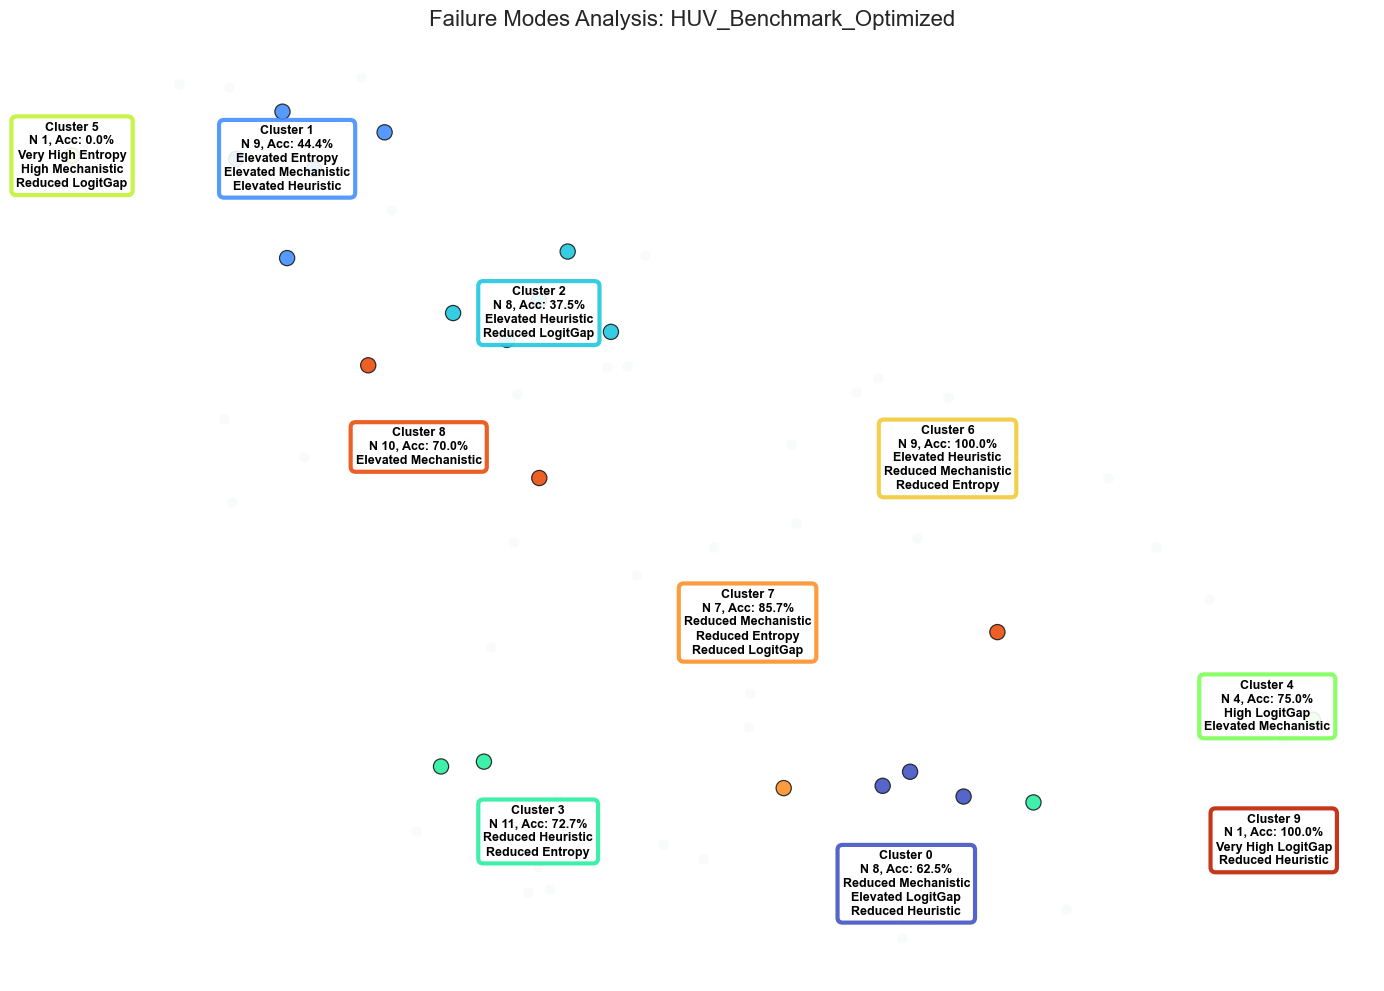

In [24]:
# Load Data
df, EXP_INFO = load_latest_data(DB_PATH)

if df is not None:
    exp_id, exp_name = EXP_INFO
    
    # --- 1. CLUSTERING ---
    features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', ] # 'Semantic', "Length"
    X = StandardScaler().fit_transform(df[features].fillna(0))
    kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
    df['Cluster'] = kmeans.fit_predict(X)

    # --- 2. HTML DASHBOARD ---
    global_medians = df[features].median()
    global_sds = df[features].std()
    
    html_out = [DASHBOARD_CSS, f'<div class="db-container">']
    html_out.append(f'<div class="db-header"><h2>Run: {exp_name} (ID: {exp_id})</h2><small>{len(df)} samples</small></div>')

    # Global Stats
    stat_cards = "".join([f'<div class="db-stat-card"><div class="db-stat-val">{global_medians[f]:.3f}</div><div class="db-stat-label">{f}</div></div>' for f in features])
    html_out.append(f'<div class="db-stat-grid">{stat_cards}</div>')

    # Per Cluster Stats
    for c in sorted(df['Cluster'].unique()):
        sub = df[df['Cluster'] == c]
        n_total = len(sub)
        acc = (sub['Correct'].sum() / n_total) * 100
        
        metrics_rows = ""
        for f in features:
            mu, sd = sub[f].mean(), sub[f].std()
            shift_val = (mu - global_medians[f]) / global_sds[f] if global_sds[f] != 0 else 0
            
            bar_color = "#c0392b" if shift_val > 1.0 else ("#2980b9" if shift_val < -1.0 else "#95a5a6")
            vis_width = min(abs(shift_val) * 15, 50) 
            vis_left = "50%" if shift_val > 0 else f"{50 - vis_width}%"
            
            metrics_rows += f"""<tr><td><b>{f}</b></td><td style="color:{bar_color}">{shift_val:+.2f} SD</td><td>{mu:.3f}</td><td>{sd:.3f}</td>
                <td><div class="shift-bar-container"><div class="shift-bar" style="left:50%; width:1px; background:#ccc;"></div><div class="shift-bar" style="left:{vis_left}; width:{vis_width}%; background:{bar_color}; opacity:0.8;"></div></div></td></tr>"""
        
        # Example Rows (Subset)
        ex_rows = ""
        for i, (_, row) in enumerate(sub.head(5).iterrows()):
            badge = '<span class="status-badge-pass">✅ Correct</span>' if row['Correct'] else '<span class="status-badge-fail">❌ Incorrect</span>'
            ex_rows += f'<div style="margin-bottom:10px;"><strong>[Ex {i+1}] {badge}</strong><br>Q: {row.get("question_text")}<br><div class="pred-box">Pred: {row.get("full_trace_text")}</div></div><hr>'
            
        html_out.append(generate_cluster_html(c, n_total, acc, metrics_rows, ex_rows))
        
    html_out.append("</div>")
    display(HTML("".join(html_out)))

    # --- 3. GRAPHING (COLOR-CODED LABELS) ---
    print("Generating t-SNE...")
    tsne = TSNE(n_components=2, perplexity=min(30, len(df)-1), random_state=42, init='pca')
    proj = tsne.fit_transform(X)
    df['x'], df['y'] = proj[:, 0], proj[:, 1]
    
    # Create explicit color map to ensure labels match points
    unique_clusters = sorted(df['Cluster'].unique())
    # Use 'turbo' palette, getting exactly N distinct colors
    palette_colors = sns.color_palette("turbo", n_colors=len(unique_clusters))
    cluster_cmap = dict(zip(unique_clusters, palette_colors))

    global_means = df[features].mean() # For labeling logic

    plt.figure(figsize=(14, 10))

    # A. Background (Correct)
    sns.scatterplot(
        data=df[df['Correct']==1], x='x', y='y', 
        color='#ecf0f1', s=60, alpha=0.3, linewidth=0, zorder=0
    )

    # B. Foreground (Incorrect/Clusters) - using explicit palette
    sns.scatterplot(
        data=df[df['Correct']==0], x='x', y='y', 
        hue='Cluster', palette=cluster_cmap, 
        s=120, alpha=0.9, edgecolor='k', legend=False, zorder=10
    )

    # C. Labels with Matching Colors
    for c in unique_clusters:
        sub = df[df['Cluster'] == c]
        failures = sub[sub['Correct'] == 0]
        
        # Determine label position (center of failures if possible)
        target = failures if len(failures) > 3 else sub
        if len(target) == 0: continue
            
        cx, cy = target['x'].median(), target['y'].median()
        label_text = f"Cluster {c}\n" + generate_label(sub, features, global_means, global_sds)
        
        # Get color for this cluster
        c_color = cluster_cmap[c]
        
        # Add Label: White Box with Colored Border matching the cluster
        plt.text(
            cx, cy, label_text, 
            horizontalalignment='center', verticalalignment='center',
            fontsize=9, fontweight='bold', color='black',
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=c_color, lw=3, alpha=0.9),
            zorder=20
        )

    plt.title(f"Failure Modes Analysis: {exp_name}", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

else:
    print("❌ Script aborted due to missing data.")

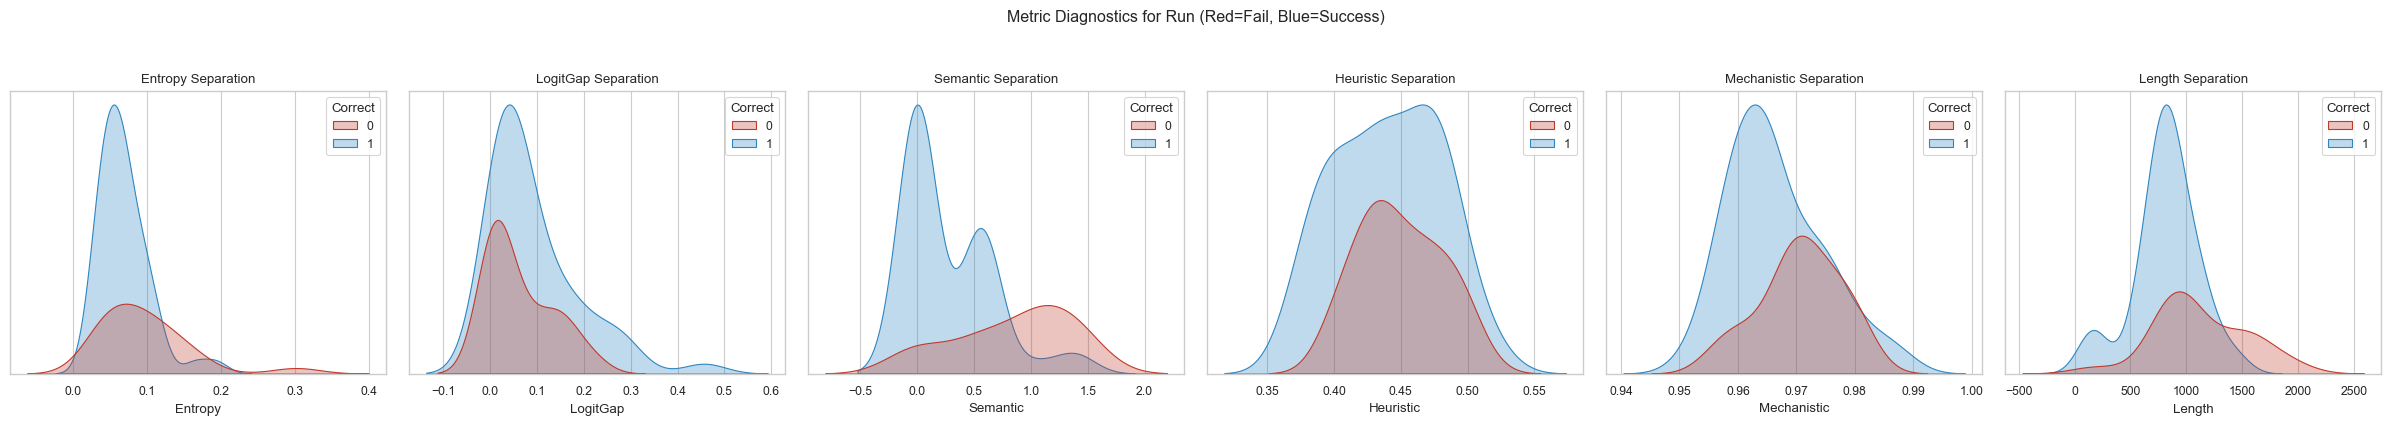

In [25]:
# Select only metrics that have data (variance > 0)
metrics = [m for m in ['Entropy', 'LogitGap', 'Semantic', 'Heuristic', 'Mechanistic', "Length"] 
           if df[m].var() > 1e-5]

fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))
if len(metrics) == 1: axes = [axes]

for i, m in enumerate(metrics):
    # Plot KDE (Smooth Histogram)
    sns.kdeplot(
        data=df, x=m, hue='Correct', 
        fill=True, palette={0: "#C0392B", 1: "#2E86C1"}, 
        alpha=0.3, warn_singular=False, ax=axes[i]
    )
    axes[i].set_title(f"{m} Separation")
    axes[i].set_ylabel("")
    axes[i].get_yaxis().set_ticks([]) # Clean look

plt.suptitle(f"Metric Diagnostics for Run (Red=Fail, Blue=Success)", y=1.05)
plt.tight_layout()
plt.show()

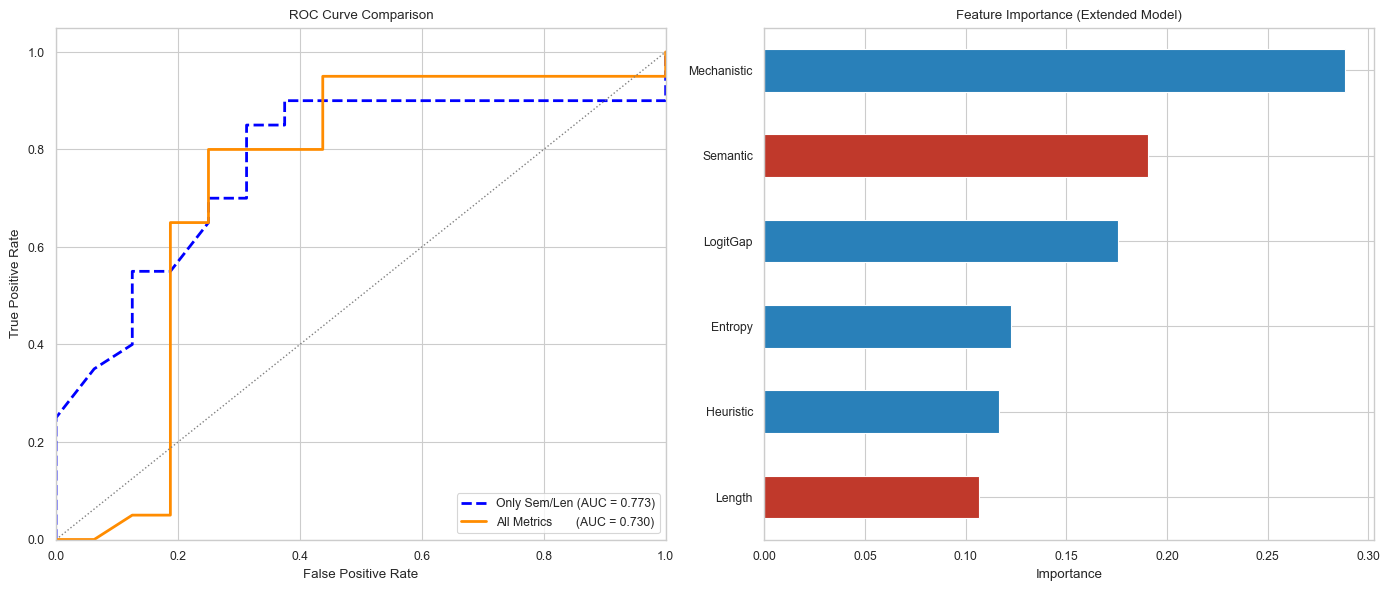

Base AUC:   0.7734
Full AUC:   0.7297
Performance Delta:       -0.0438


In [26]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# --- 1. PREP & SPLIT ---
# We define two feature sets to compare
base_features = ['Semantic', 'Length'] 
all_features  = base_features + ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic']

# Leakage-free split (Same split used for both models)
unique_questions = df['question_text'].unique()
train_q, test_q = train_test_split(unique_questions, test_size=0.5, random_state=42)

train_df = df[df['question_text'].isin(train_q)].copy()
test_df  = df[df['question_text'].isin(test_q)].copy()
y_train, y_test = train_df['Correct'], test_df['Correct']

# --- 2. TRAINING FUNCTION ---
def train_and_eval(features, label):
    # Scale specific features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[features].fillna(0))
    X_test  = scaler.transform(test_df[features].fillna(0))
    
    # Train
    clf = RandomForestClassifier(n_estimators=200, max_depth=5, class_weight='balanced', random_state=42)
    clf.fit(X_train, y_train)
    
    # Predict
    probs = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    
    return fpr, tpr, roc_auc, clf

# Run both models
fpr_base, tpr_base, auc_base, clf_base = train_and_eval(base_features, "Base")
fpr_full, tpr_full, auc_full, clf_full = train_and_eval(all_features, "Extended")

# --- 3. COMPARATIVE VISUALIZATION ---
plt.figure(figsize=(14, 6))

# Plot A: ROC Comparison
plt.subplot(1, 2, 1)
plt.plot(fpr_base, tpr_base, color='blue', lw=2, linestyle='--', label=f'Only Sem/Len (AUC = {auc_base:.3f})')
plt.plot(fpr_full, tpr_full, color='darkorange', lw=2, label=f'All Metrics       (AUC = {auc_full:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")

# Plot B: Feature Importance (Extended Model)
plt.subplot(1, 2, 2)
importances = pd.Series(clf_full.feature_importances_, index=all_features).sort_values()
colors = ['#c0392b' if x in ['Semantic', 'Length'] else '#2980b9' for x in importances.index]
importances.plot(kind='barh', color=colors)
plt.title('Feature Importance (Extended Model)')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

# --- 4. STATS SUMMARY ---
print(f"Base AUC:   {auc_base:.4f}")
print(f"Full AUC:   {auc_full:.4f}")
print(f"Performance Delta:       {(auc_full - auc_base):+.4f}")

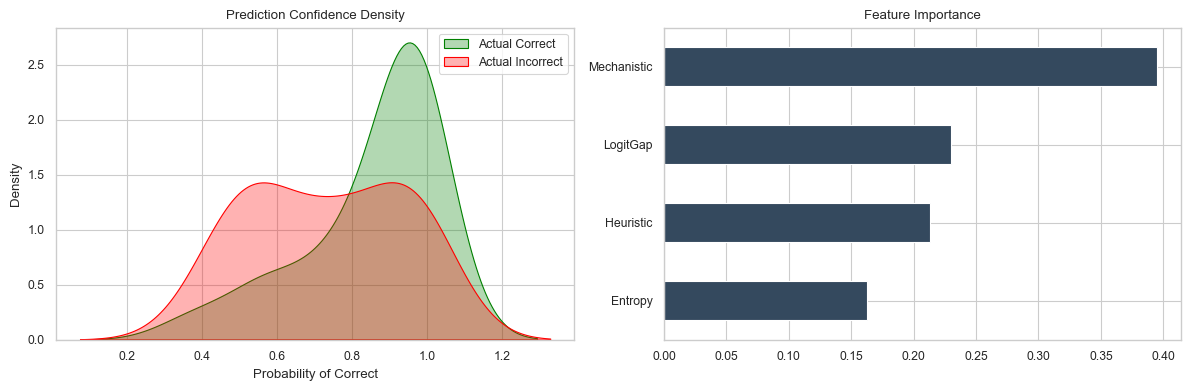

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc

# --- 1. PREP & SPLIT ---
features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic']
unique_questions = df['question_text'].unique()

train_q, test_q = train_test_split(unique_questions, test_size=0.5, random_state=42)
train_df = df[df['question_text'].isin(train_q)].copy()
test_df  = df[df['question_text'].isin(test_q)].copy()

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[features].fillna(0))
X_test  = scaler.transform(test_df[features].fillna(0))
y_train, y_test = train_df['Correct'], test_df['Correct']

# --- 2. TRAIN & PREDICT ---
clf = RandomForestClassifier(n_estimators=200, max_depth=5, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

probs = clf.predict_proba(X_test)[:, 1]

# Attach predictions back to the dataframe for inspection
test_df['Prob_Correct'] = probs
test_df['Pred_Label'] = (probs > 0.5).astype(int)

# --- 3. VISUALIZATION (Compact) ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.kdeplot(x=test_df[test_df['Correct']==1]['Prob_Correct'], fill=True, color='green', label='Actual Correct', alpha=0.3)
sns.kdeplot(x=test_df[test_df['Correct']==0]['Prob_Correct'], fill=True, color='red', label='Actual Incorrect', alpha=0.3)
plt.title('Prediction Confidence Density')
plt.xlabel('Probability of Correct')
plt.legend()

plt.subplot(1, 2, 2)
pd.Series(clf.feature_importances_, index=features).sort_values().plot(kind='barh', color='#34495e')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

# --- 4. QUALITATIVE VERIFICATION ---
def print_samples(title, subset, n=3):
    print(f"\n--- {title} (Showing {min(n, len(subset))}/{len(subset)}) ---")
    if len(subset) == 0:
        print("(No samples found in this category)")
        return
    
    # Sort by confidence to see the most egregious examples
    if "False Positive" in title: 
        # Model was sure it was Right (Prob high), but was Wrong
        subset = subset.sort_values('Prob_Correct', ascending=False)
    elif "False Negative" in title:
        # Model was sure it was Wrong (Prob low), but was Right
        subset = subset.sort_values('Prob_Correct', ascending=True)
        
    for i, (_, row) in enumerate(subset.head(n).iterrows()):
        print(f"[{i+1}] Conf: {row['Prob_Correct']:.2f} | Len: {row.get('Length', 'N/A')}")
        print(f"    Q: {str(row.get('question_text'))[:]}")
        print(f"    Trace Snippet: {str(row.get('full_trace_text'))[:]}")

# # 1. FALSE POSITIVES (Model said CORRECT, actually WRONG) - "Overconfident"
# fp = test_df[(test_df['Correct'] == 0) & (test_df['Pred_Label'] == 1)]
# print_samples("FALSE POSITIVES (Model Hallucinations?)", fp)

# # 2. FALSE NEGATIVES (Model said WRONG, actually CORRECT) - "Missed Gems"
# fn = test_df[(test_df['Correct'] == 1) & (test_df['Pred_Label'] == 0)]
# print_samples("FALSE NEGATIVES (Model Pessimism)", fn)

# # 3. TRUE NEGATIVES (Model said WRONG, actually WRONG) - "Correct Rejections"
# tn = test_df[(test_df['Correct'] == 0) & (test_df['Pred_Label'] == 0)]
# print_samples("TRUE NEGATIVES (Caught Failures)", tn)